# Init

In [1]:
%run ../scripts/bootstrap_notebook.py

import importlib
import sys
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from pprint import pprint

import laboneq.dsl.quantum.qpu as qpu_mod
import numpy as np
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.dsl.calibration import Oscillator, SignalCalibration
from laboneq.dsl.device import DeviceSetup
from laboneq.dsl.enums import ModulationType
from laboneq.serializers import load
from laboneq.simple import *

repo_root = PROJECT_ROOT

# descriptor = generate_descriptor(
#     #pqsc=[""], # 장비 여러개 사용시
#     shfqc_6=["DEV12256"],
#     number_data_qubits=3,
#     multiplex=True,
#     number_multiplex=6,
#     include_cr_lines=False,
#     include_ef_lines=True,
#     get_zsync=False,  # Only set to True when using real device
#     save=True,
#     filename="1port",
#     ip_address="192.168.0.83",
# )

# descriptor
# setup = DeviceSetup.from_descriptor(yaml_text=descriptor, server_host="192.168.0.83")
descriptor_candidates = [
    repo_root / "configs" / "descriptors" / "1port.yaml",
    Path("../configs/descriptors/1port.yaml"),
    Path("configs/descriptors/1port.yaml"),
]
descriptor_path = next((p for p in descriptor_candidates if p.exists()), descriptor_candidates[0])
setup = DeviceSetup.from_yaml(filepath=str(descriptor_path.resolve()), server_host="192.168.0.83")
setup.instruments[0].device_options = "SHFQC/PLUS/QC6CH"

bus_ids = [f"b{i}" for i in range(3)]
bus_port = [3, 4, 5]  # used 1,2,3 for qubit drive

for i, bus in zip(bus_port, bus_ids):
    setup.add_connections(
        setup.instruments[0].uid,
        # each bus uses its own drive:
        create_connection(
            to_signal=f"{bus}/drive",
            ports=f"SGCHANNELS/{i}/OUTPUT",
        ),
    )

# Calibrate qubit drive/measure lines for oscillator phase increments
qubit_ids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
for qubit in qubit_ids:
    for line, frequency, mod_type in [
        ("drive", 5e9, ModulationType.HARDWARE),
        ("drive_ef", 6e9, ModulationType.HARDWARE),
        ("measure", 4e9, ModulationType.SOFTWARE),
    ]:
        logical_signal = setup.logical_signal_by_uid(f"{qubit}/{line}")
        oscillator = Oscillator(modulation_type=mod_type)
        logical_signal.calibration = SignalCalibration(
            local_oscillator=Oscillator(frequency=frequency),
            oscillator=oscillator,
        )
        if line == "measure":
            acquire_signal = setup.logical_signal_by_uid(f"{qubit}/acquire")
            acquire_signal.calibration = SignalCalibration(
                local_oscillator=Oscillator(frequency=frequency),
                oscillator=oscillator,
            )

from qubit_experiment.qpu_types.fixed_transmon import (
    FixedTransmonQubit,
    FixedTransmonQubitParameters,
)
from qubit_experiment.qpu_types.bus_cavity import BusCavity, BusCavityParameters
from qubit_experiment.qpu_types.fixed_transmon.operations import FixedTransmonOperations
from qubit_experiment.qpu_types.bus_cavity.operations import BusCavityOperations
from laboneq.dsl.quantum.qpu import QPU, QuantumPlatform
from qubit_experiment.helper import load_qubit_parameters, save_qubit_parameters

qubit_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
bus_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("b")]

qubits = FixedTransmonQubit.from_device_setup(setup, qubit_uids=qubit_uids)
buses = BusCavity.from_device_setup(setup, qubit_uids=bus_uids)

qpu = QPU(
    quantum_elements={"qubits": qubits, "bus": buses},
    quantum_operations=[FixedTransmonOperations, BusCavityOperations],
)


def find_latest_json(folder_path: Path) -> Path | None:
    timestamps = []
    for candidate in folder_path.iterdir():
        try:
            timestamp_str = candidate.name.split("_", 1)[0]
            timestamp = datetime.strptime(timestamp_str, "%Y%m%d-%H%M%S")
            timestamps.append((timestamp, candidate))
        except ValueError:
            continue

    if timestamps:
        return max(timestamps, key=lambda item: item[0])[1]
    return None


qb_pars_file = find_latest_json(repo_root / "qpu_parameters")
if qb_pars_file is None:
    raise FileNotFoundError(f"No qpu_parameters snapshot found under {repo_root / 'qpu_parameters'}")
print(f"LOADED: {qb_pars_file}")


class CombinedOperations(FixedTransmonOperations, BusCavityOperations):
    pass


qpu_mod.CombinedOperations = CombinedOperations

# Backward-compatibility aliases for legacy serialized qpu_parameters snapshots.
for legacy_name, canonical_name in {
    "qpu_types": "qubit_experiment.qpu_types",
    "qpu_types.fixed_transmon": "qubit_experiment.qpu_types.fixed_transmon",
    "qpu_types.fixed_transmon.qubit_types": "qubit_experiment.qpu_types.fixed_transmon.qubit_types",
    "qpu_types.fixed_transmon.operations": "qubit_experiment.qpu_types.fixed_transmon.operations",
    "qpu_types.bus_cavity": "qubit_experiment.qpu_types.bus_cavity",
    "qpu_types.bus_cavity.bus_types": "qubit_experiment.qpu_types.bus_cavity.bus_types",
    "qpu_types.bus_cavity.operations": "qubit_experiment.qpu_types.bus_cavity.operations",
}.items():
    sys.modules.setdefault(legacy_name, importlib.import_module(canonical_name))

qpu = load(qb_pars_file)

buses = qpu.groups.bus
qubits = qpu.groups.qubits

from laboneq.simple import workflow

folder_store = workflow.logbook.FolderStore(
    "/Users/yalgaeahn/Library/CloudStorage/SynologyDrive-KAIST/RIP_APS_2026/experiment_store"
)
folder_store.activate()


Project root: /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP
Added to sys.path:
  - /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP
  - /Users/yalgaeahn/Research/20_Projects/qubit-experiment
LOADED: /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP/qpu_parameters/20260303-0948_3Q_tomo


In [2]:
session = Session(setup)
session.connect(ignore_version_mismatch=False, do_emulation=True)


[2026.03.11 16:32:34.978] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/yalgaeahn/Research/20_Projects/qubit-experiment/projects/2026_selectiveRIP/noteforTG/laboneq_output/log
[2026.03.11 16:32:34.979] INFO    VERSION: laboneq 25.10.3
[2026.03.11 16:32:34.980] INFO    Connecting to data server at 192.168.0.83:8004
[2026.03.11 16:32:34.981] INFO    Connected to Zurich Instruments LabOne Data Server version 25.10.1.4 at 192.168.0.83:8004
[2026.03.11 16:32:34.982] INFO    Configuring the device setup
[2026.03.11 16:32:34.983] INFO    The device setup is configured


# Quantum State Tomography


## Multiplexed IQ cloud

[2026.03.11 16:32:35.495] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:32:35.496] INFO      Workflow 'iq_cloud': execution started at 2026-03-11 07:32:35.495620Z         
[2026.03.11 16:32:35.496] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:32:35.506] INFO    Task 'temporary_qpu': started at 2026-03-11 07:32:35.506784Z
[2026.03.11 16:32:35.507] INFO    Task 'temporary_qpu': ended at 2026-03-11 07:32:35.507818Z
[2026.03.11 16:32:35.512] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-03-11 
[2026.03.11 16:32:35.512] INFO    07:32:35.512031Z
[2026.03.11 16:32:35.513] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-03-11 07:32:35.513322Z
[2026.03.11 16:32:35.514] INFO    Task 'create_experiment': started at 2026-03-11 07:32:35.514812Z
[2026.03.11 16:32:35.525] INFO    Task 'create_experiment': ended at 2026-03-11 07:32:35.524759Z
[202

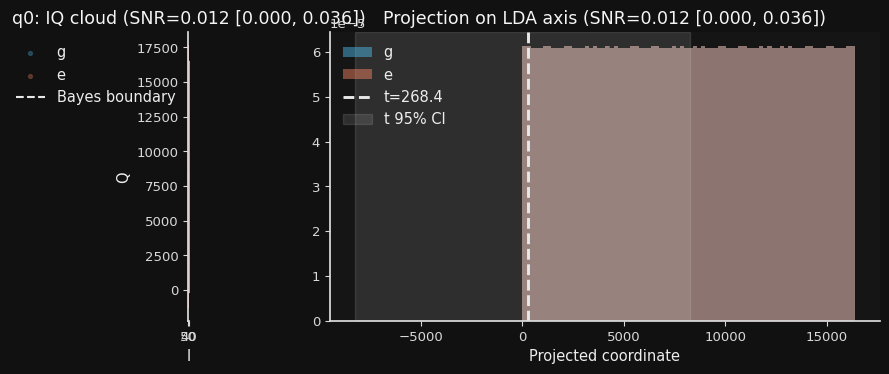

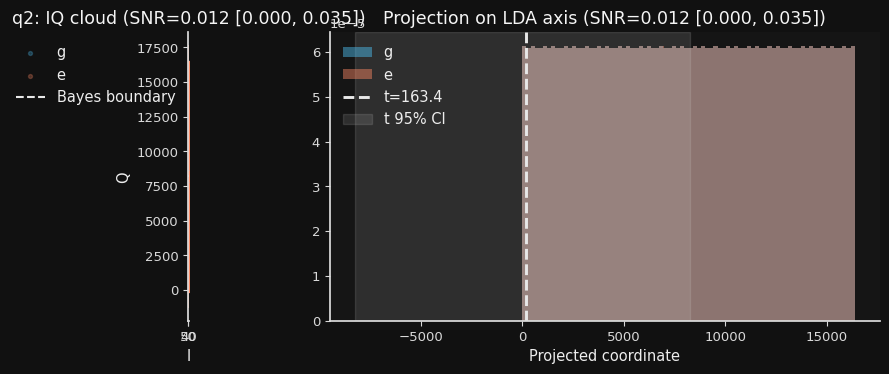

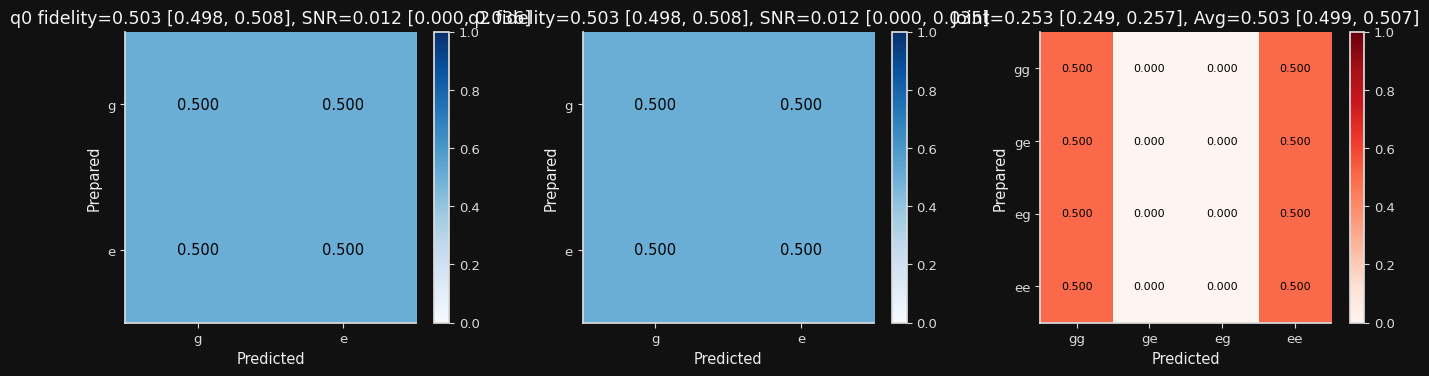

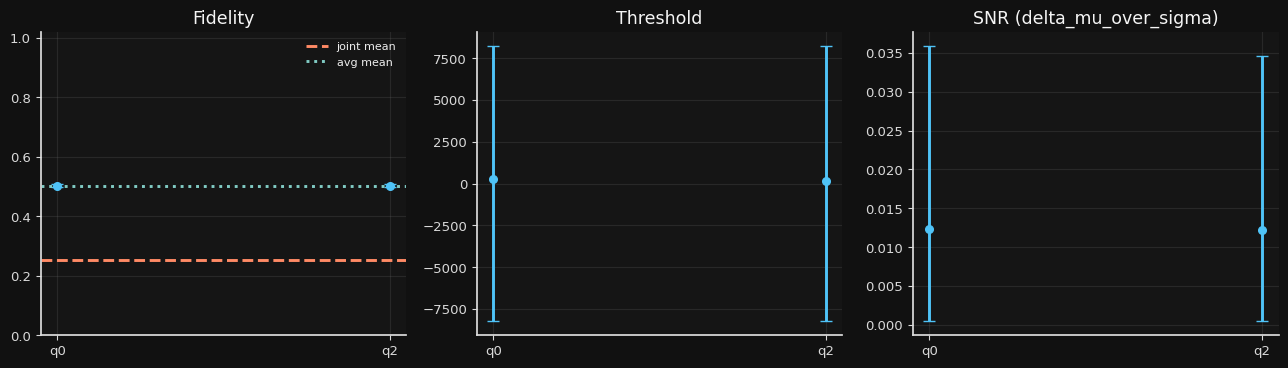

In [3]:
from qubit_experiment.experiments import iq_cloud_common, iq_cloud
q = qubits[0]
qq = qubits[2]

temporary_parameters = {}
q_temp_pars = deepcopy(q.parameters)
qq_temp_pars = deepcopy(qq.parameters)

# q_temp_pars.readout_integration_delay = 180e-9
# qq_temp_pars.readout_integration_delay= 180e-9
# q_temp_pars.readout_length = 1.6e-6
# qq_temp_pars.readout_length = 1.6e-6
temporary_parameters[q.uid] = q_temp_pars
temporary_parameters[qq.uid] = qq_temp_pars
#######################################################################

options = iq_cloud.experiment_workflow.options()
options.do_analysis(True)
options.update(False)
#options.count(1024)

iq_result = iq_cloud.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q,qq],
    temporary_parameters=temporary_parameters,
    options=options,
).run()


## 2Q QST

In [4]:
from qubit_experiment.analysis import twoq_qst as twoq_qst_analysis
from qubit_experiment.experiments import twoq_qst
q = qubits[0]
qq = qubits[2]

temporary_parameters = {}
q_temp_pars = deepcopy(q.parameters)
qq_temp_pars = deepcopy(qq.parameters)
temporary_parameters[q.uid] = q_temp_pars
temporary_parameters[qq.uid] = qq_temp_pars


ctrl = q
targ = qq

bus = [buses[0], buses[1], buses[2]]

RUN_CONVERGENCE_VALIDATION = False
RUN_SHOT_SWEEP_CONVERGENCE = True
CONVERGENCE_REPEATS = 1
CONVERGENCE_STATES = ("00", "01", "10", "11", "++", "+-", "-+", "--")
SHOT_SWEEP_LOG2_VALUES = tuple(range(3, 9))
SHOT_SWEEP_STATES = CONVERGENCE_STATES
SHOT_SWEEP_REPEATS_PER_POINT = 3

qst_options = twoq_qst.experiment_workflow.options()
qst_options.do_analysis(True)
qst_options.do_readout_calibration(True)
qst_options.initial_state("++")
qst_options.custom_prep(False)
qst_options.do_convergence_validation(RUN_CONVERGENCE_VALIDATION)
qst_options.convergence_repeats_per_state(CONVERGENCE_REPEATS)
qst_options.convergence_suite_states(CONVERGENCE_STATES)
qst_options.convergence_do_plotting(True)
qst_options.do_shot_sweep_convergence(RUN_SHOT_SWEEP_CONVERGENCE)
qst_options.shot_sweep_log2_values(SHOT_SWEEP_LOG2_VALUES)
qst_options.shot_sweep_suite_states(SHOT_SWEEP_STATES)
qst_options.shot_sweep_repeats_per_point(SHOT_SWEEP_REPEATS_PER_POINT)
qst_options.shot_sweep_do_plotting(True)

analysis_options = twoq_qst_analysis.analysis_workflow.options()
analysis_options.do_plotting(True)
# analysis_options.max_mle_iterations(4000)

twoq_qst_output = twoq_qst.run_bundle(
    session=session,
    qpu=qpu,
    qubits=[ctrl, targ],
    bus=bus,
    temporary_parameters=temporary_parameters,
    options=qst_options,
    analysis_options=analysis_options,
)

print("Workflow output keys:", list(twoq_qst_output.keys()))
if twoq_qst_output.get("analysis_result") is not None:
    print("Main analysis metric keys:", list(twoq_qst_output["analysis_result"]["metrics"].keys()))
if twoq_qst_output.get("convergence_report") is not None:
    print("Convergence report keys:", list(twoq_qst_output["convergence_report"].keys()))
if twoq_qst_output.get("shot_sweep_report") is not None:
    print("Shot sweep report keys:", list(twoq_qst_output["shot_sweep_report"].keys()))


[2026.03.11 16:32:55.566] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:32:55.567] INFO      Workflow 'twoq_qst': execution started at 2026-03-11 07:32:55.565986Z         
[2026.03.11 16:32:55.568] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:32:55.581] INFO    Task 'resolve_target_configuration': started at 2026-03-11 07:32:55.580892Z
[2026.03.11 16:32:55.582] INFO    Task 'resolve_target_configuration': ended at 2026-03-11 07:32:55.581966Z
[2026.03.11 16:32:55.582] INFO    Task 'temporary_qpu': started at 2026-03-11 07:32:55.582563Z
[2026.03.11 16:32:55.583] INFO    Task 'temporary_qpu': ended at 2026-03-11 07:32:55.583399Z
[2026.03.11 16:32:55.586] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-03-11 
[2026.03.11 16:32:55.586] INFO    07:32:55.585898Z
[2026.03.11 16:32:55.586] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-03-11

## 3Q QST

In [5]:
from qubit_experiment.analysis import threeq_qst as threeq_qst_analysis
from qubit_experiment.experiments import threeq_qst

spec = qubits[1]
ctrl = qubits[0]
targ = qubits[2]

threeq_temporary_parameters = {}
for qubit in (spec, ctrl, targ):
    threeq_temporary_parameters[qubit.uid] = deepcopy(qubit.parameters)

threeq_bus = [buses[0], buses[1], buses[2]]

RUN_3Q_CONVERGENCE_VALIDATION = False
RUN_3Q_SHOT_SWEEP_CONVERGENCE = True
THREEQ_CONVERGENCE_REPEATS = 1
THREEQ_CONVERGENCE_STATES = ("000", "111", "+++", "---")
THREEQ_SHOT_SWEEP_LOG2_VALUES = tuple(range(3, 4))
THREEQ_SHOT_SWEEP_STATES = THREEQ_CONVERGENCE_STATES
THREEQ_SHOT_SWEEP_REPEATS_PER_POINT = 3

threeq_qst_options = threeq_qst.experiment_workflow.options()
threeq_qst_options.do_analysis(True)
threeq_qst_options.do_readout_calibration(True)
threeq_qst_options.initial_state("+++")
threeq_qst_options.custom_prep(False)
threeq_qst_options.do_convergence_validation(RUN_3Q_CONVERGENCE_VALIDATION)
threeq_qst_options.convergence_repeats_per_state(THREEQ_CONVERGENCE_REPEATS)
threeq_qst_options.convergence_suite_states(THREEQ_CONVERGENCE_STATES)
threeq_qst_options.convergence_do_plotting(True)
threeq_qst_options.do_shot_sweep_convergence(RUN_3Q_SHOT_SWEEP_CONVERGENCE)
threeq_qst_options.shot_sweep_log2_values(THREEQ_SHOT_SWEEP_LOG2_VALUES)
threeq_qst_options.shot_sweep_suite_states(THREEQ_SHOT_SWEEP_STATES)
threeq_qst_options.shot_sweep_repeats_per_point(THREEQ_SHOT_SWEEP_REPEATS_PER_POINT)
threeq_qst_options.shot_sweep_do_plotting(True)

threeq_analysis_options = threeq_qst_analysis.analysis_workflow.options()
threeq_analysis_options.do_plotting(True)
# threeq_analysis_options.max_mle_iterations(4000)

threeq_qst_output = threeq_qst.run_bundle(
    session=session,
    qpu=qpu,
    qubits=[spec, ctrl, targ],
    bus=threeq_bus,
    temporary_parameters=threeq_temporary_parameters,
    options=threeq_qst_options,
    analysis_options=threeq_analysis_options,
)

print("Workflow output keys:", list(threeq_qst_output.keys()))
if threeq_qst_output.get("analysis_result") is not None:
    print(
        "3Q analysis metric keys:",
        list(threeq_qst_output["analysis_result"]["metrics"].keys()),
    )
if threeq_qst_output.get("convergence_report") is not None:
    print(
        "3Q convergence report keys:",
        list(threeq_qst_output["convergence_report"].keys()),
    )
if threeq_qst_output.get("shot_sweep_report") is not None:
    print(
        "3Q shot sweep report keys:",
        list(threeq_qst_output["shot_sweep_report"].keys()),
    )


[2026.03.11 16:33:12.826] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:33:12.826] INFO      Workflow 'threeq_qst': execution started at 2026-03-11 07:33:12.826250Z       
[2026.03.11 16:33:12.827] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.11 16:33:12.838] INFO    Task 'resolve_target_configuration': started at 2026-03-11 07:33:12.838040Z
[2026.03.11 16:33:12.838] INFO    Task 'resolve_target_configuration': ended at 2026-03-11 07:33:12.838862Z
[2026.03.11 16:33:12.839] INFO    Task 'temporary_qpu': started at 2026-03-11 07:33:12.839423Z
[2026.03.11 16:33:12.840] INFO    Task 'temporary_qpu': ended at 2026-03-11 07:33:12.840541Z
[2026.03.11 16:33:12.843] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-03-11 
[2026.03.11 16:33:12.844] INFO    07:33:12.843734Z
[2026.03.11 16:33:12.845] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-03-11